# gptTest: GPT-5-nano as generator, thinking vs non-thinking

See `plan.md` in this folder for the full design. Tests whether swapping the generator
from local `Llama-3.1-8B-Instruct` to OpenAI `gpt-5-nano` (with and without extended
reasoning) improves correctness/faithfulness/relevancy on the 21 "universal failure"
queries from `results/p1_universal_failures.jsonl`. Retrieval, reference answers
(`reference_14b`/`reference_72b`), and the scoring judge (`gpt-5.5`) are all held
constant so results are directly comparable to the existing baseline and P2 variant
scores.

## Cell group 1: setup + data loading

In [1]:
import json
from pathlib import Path

from dotenv import load_dotenv

# Notebook cwd is this folder (gptTest/), so shared inputs are one level up.
DATA_DIR = Path("../data")
MAIN_RESULTS_DIR = Path("../results")
ENV_PATH = Path("../.env")

# This folder's own outputs stay local, per this experiment's logging convention.
OUT_DIR = Path("results")
FIG_DIR = Path("figures")
OUT_DIR.mkdir(exist_ok=True)
FIG_DIR.mkdir(exist_ok=True)

load_dotenv(ENV_PATH)


def load_jsonl(path: Path) -> list[dict]:
    return [json.loads(l) for l in path.read_text(encoding="utf-8").splitlines() if l.strip()]


failures = load_jsonl(MAIN_RESULTS_DIR / "p1_universal_failures.jsonl")
clauses = load_jsonl(DATA_DIR / "clauses.jsonl")
clause_lookup = {c["clause_id"]: c for c in clauses}
test_set = load_jsonl(DATA_DIR / "test_set.jsonl")
ts_lookup = {r["query"]: r for r in test_set}

print(f"Universal-failure queries loaded: {len(failures)}")
print(f"Clauses loaded: {len(clause_lookup)}")
print(f"Test set rows loaded: {len(ts_lookup)}")
assert len(failures) == 21, f"expected 21 universal-failure queries, got {len(failures)}"
assert all(r["query"] in ts_lookup for r in failures), "every failure query must be in test_set.jsonl"
print("OK: all 21 failure queries resolve against test_set.jsonl")


Universal-failure queries loaded: 21
Clauses loaded: 2568
Test set rows loaded: 50
OK: all 21 failure queries resolve against test_set.jsonl


## Cell group 2: gpt-5-nano API capability probe

Confirms, on a single query, before spending 42 real generation calls: whether
`reasoning_effort` is accepted, whether `response_format={"type": "json_object"}` works,
and what `max_completion_tokens` budget is actually needed for both conditions (reasoning
tokens are deducted from the same budget as visible output — this project has hit empty
replies from an undersized budget twice before, see `plan.md`).

In [2]:
import time

from openai import OpenAI

GEN_MODEL = "gpt-5-nano"
client = OpenAI()

SYSTEM_PROMPT = """You are an AML compliance analyst. Answer using ONLY the regulatory clauses below.

Rules:
1. Every factual claim must be followed by [clause_id] inline.
2. State explicitly if the provided context does not answer the question.
3. Output valid JSON with two keys:
   - answer: your response with inline [clause_id] citations
   - citations: list of clause_id strings you cited

Context:
{context}"""


def format_context(retrieved_ids: list[str], clause_lookup: dict) -> str:
    parts = []
    for cid in retrieved_ids:
        clause = clause_lookup.get(cid)
        if clause:
            parts.append(f"[{cid}]\n{clause['text'][:800]}")
    return "\n\n---\n\n".join(parts)


probe_row = failures[0]
probe_query = probe_row["query"]
probe_retrieved = probe_row["answers_8b"]["hybrid"]["retrieved"]
probe_context = format_context(probe_retrieved, clause_lookup)
print(f"Probe query: {probe_query!r}")
print(f"Retrieved clauses: {len(probe_retrieved)}")


def probe_call(reasoning_effort: str | None, max_completion_tokens: int = 4096):
    kwargs = dict(
        model=GEN_MODEL,
        messages=[
            {"role": "system", "content": SYSTEM_PROMPT.format(context=probe_context)},
            {"role": "user", "content": probe_query},
        ],
        response_format={"type": "json_object"},
        max_completion_tokens=max_completion_tokens,
    )
    if reasoning_effort is not None:
        kwargs["reasoning_effort"] = reasoning_effort
    t0 = time.time()
    try:
        resp = client.chat.completions.create(**kwargs)
    except Exception as exc:
        print(f"  ERROR (reasoning_effort={reasoning_effort!r}): {type(exc).__name__}: {exc}")
        return None
    dt = time.time() - t0
    choice = resp.choices[0]
    content = choice.message.content
    usage = resp.usage
    print(f"  reasoning_effort={reasoning_effort!r}: {dt:.1f}s, finish_reason={choice.finish_reason!r}")
    print(f"  usage: {usage}")
    print(f"  content length: {len(content) if content else 0} chars")
    if content:
        try:
            parsed = json.loads(content)
            print(f"  JSON parse OK, keys={list(parsed.keys())}, answer preview: {parsed.get('answer', '')[:150]!r}")
        except json.JSONDecodeError as exc:
            print(f"  JSON parse FAILED: {exc}; raw preview: {content[:200]!r}")
    else:
        print("  EMPTY content")
    return resp


print("\n--- Probe: minimal reasoning effort ---")
resp_minimal = probe_call("minimal")

print("\n--- Probe: high reasoning effort ---")
resp_high = probe_call("high")


Probe query: 'A person accused under section 327 of POCA 2002 may rely on an authorised disclosure as a defence — which section of POCA governs such disclosures, and what must the disclosure consist of?'
Retrieved clauses: 10

--- Probe: minimal reasoning effort ---


  reasoning_effort='minimal': 4.7s, finish_reason='stop'
  usage: CompletionUsage(completion_tokens=226, prompt_tokens=1941, total_tokens=2167, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0))
  content length: 1021 chars
  JSON parse OK, keys=['answer', 'citations'], answer preview: 'The disclosures are governed by POCA section 333A. A defence is available where the disclosure was made in the manner specified by 333C, and the discl'

--- Probe: high reasoning effort ---


  reasoning_effort='high': 27.5s, finish_reason='length'
  usage: CompletionUsage(completion_tokens=4096, prompt_tokens=1941, total_tokens=6037, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=4096, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0))
  content length: 0 chars
  EMPTY content


In [ ]:
print("--- Probe: high reasoning effort, larger budget ---")
resp_high_8k = probe_call("high", max_completion_tokens=8192)


--- Probe: high reasoning effort, larger budget ---


In [6]:
print("--- Probe: medium reasoning effort ---")
resp_medium = probe_call("medium", max_completion_tokens=8192)


--- Probe: medium reasoning effort ---


  reasoning_effort='medium': 14.5s, finish_reason='stop'
  usage: CompletionUsage(completion_tokens=2152, prompt_tokens=1941, total_tokens=4093, completion_tokens_details=CompletionTokensDetails(accepted_prediction_tokens=0, audio_tokens=0, reasoning_tokens=1920, rejected_prediction_tokens=0), prompt_tokens_details=PromptTokensDetails(audio_tokens=0, cached_tokens=0))
  content length: 953 chars
  JSON parse OK, keys=['answer', 'citations'], answer preview: 'The authorised disclosures are governed by section 333A of POCA 2002. [poca_2002_s333A] The authorised disclosures are set out in section 333C, which '


**Probe conclusion**: non-thinking = `reasoning_effort="minimal"`, thinking =
`reasoning_effort="medium"` (not `"high"` — see `plan.md` Change log, 2026-07-10).
Both conditions use `max_completion_tokens=8192`.

## Cell group 3: generate answers, non-thinking condition (`reasoning_effort="minimal"`)

In [7]:
MAX_COMPLETION_TOKENS = 8192


def generate_condition(reasoning_effort: str, variant: str, out_path: Path) -> None:
    n_errors = 0
    with out_path.open("w", encoding="utf-8") as f:
        for i, row in enumerate(failures, start=1):
            query = row["query"]
            retrieved_ids = row["answers_8b"]["hybrid"]["retrieved"]
            context = format_context(retrieved_ids, clause_lookup)
            t0 = time.time()
            answer, citations, error = "", [], None
            try:
                resp = client.chat.completions.create(
                    model=GEN_MODEL,
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT.format(context=context)},
                        {"role": "user", "content": query},
                    ],
                    response_format={"type": "json_object"},
                    max_completion_tokens=MAX_COMPLETION_TOKENS,
                    reasoning_effort=reasoning_effort,
                )
                content = resp.choices[0].message.content
                if not content:
                    error = f"empty content, finish_reason={resp.choices[0].finish_reason!r}"
                else:
                    parsed = json.loads(content)
                    answer = parsed.get("answer", "")
                    citations = parsed.get("citations", [])
            except Exception as exc:
                error = f"{type(exc).__name__}: {exc}"
                n_errors += 1

            out = {
                "query": query, "query_type": row["query_type"], "gold_ids": row["gold_ids"],
                "config": "hybrid", "variant": variant, "reasoning_effort": reasoning_effort,
                "retrieved": retrieved_ids, "answer": answer, "citations": citations,
                "error": error,
            }
            f.write(json.dumps(out, ensure_ascii=False) + "\n")
            f.flush()
            status = "ERROR" if error else "ok"
            print(f"[{i}/{len(failures)}] {status:<5} {query[:50]!r} -> {len(answer)} chars ({time.time()-t0:.1f}s)")

    print(f"\nDone: {len(failures)} rows written to {out_path} ({n_errors} errors)")


generate_condition("minimal", "gpt5nano_base", OUT_DIR / "answers_nonthinking.jsonl")


[1/21] ok    'A person accused under section 327 of POCA 2002 ma' -> 772 chars (2.7s)


[2/21] ok    "How does section 335 of POCA 2002 define 'appropri" -> 344 chars (1.4s)


[3/21] ok    "MLR 2017 regulation 29 specifies it applies 'in ad" -> 785 chars (2.1s)


[4/21] ok    "MLR 2017 regulation 3 defines 'money laundering' b" -> 391 chars (2.0s)


[5/21] ok    'MLR 2017 regulation 44 requires trustees to mainta' -> 758 chars (2.6s)


...

[17/21] ok    'Under section 336 of POCA 2002, what conditions mu' -> 602 chars (1.6s)


[18/21] ok    'What authorised disclosure under POCA 2002 can pre' -> 670 chars (2.1s)


[19/21] ok    'What information must a credit institution gather ' -> 519 chars (1.5s)


[20/21] ok    'What must a credit institution apply under MLR 201' -> 645 chars (1.7s)


[21/21] ok    'What three conditions must all be satisfied for a ' -> 493 chars (2.5s)

Done: 21 rows written to results\answers_nonthinking.jsonl (0 errors)


## Cell group 4: generate answers, thinking condition (`reasoning_effort="medium"`)

Expect ~14-15s/row based on the probe (~5 min total for 21 rows) — likely to exceed the
MCP client's response window even with a generous `timeout`. Results are flushed to disk
per row, so if the tool call itself times out client-side, the recovery is: check
`list_kernels` for idle state, reconnect, then read `results/answers_thinking.jsonl`
directly rather than re-running (per the known Jupyter MCP flakiness pattern, see the
outer project's `STATUS.md`).

In [ ]:
generate_condition("medium", "gpt5nano_thinking", OUT_DIR / "answers_thinking.jsonl")


[1/21] ok    'A person accused under section 327 of POCA 2002 ma' -> 560 chars (37.9s)


In [9]:
# Loading rather than re-running: the previous cell's 21 calls already completed and
# re-running would re-spend on them for no reason.
thinking_answers = load_jsonl(OUT_DIR / "answers_thinking.jsonl")
n_errors = sum(1 for r in thinking_answers if r.get("error"))
print(f"answers_thinking.jsonl: {len(thinking_answers)} rows, {n_errors} errors")
assert len(thinking_answers) == 21


answers_thinking.jsonl: 21 rows, 0 errors


## Cell group 5: score both conditions

Same methodology as `experiment/p2_structured_prompting.py`: `gpt-5.5` judge (unchanged),
RAGAS `Faithfulness`/`AnswerRelevancy` + local HF embeddings, cosine similarity, and a
yes/no `llm_grade` correctness check — each scored against both `reference_14b` and
`reference_72b`. Held identical to prior experiments so results are directly comparable.

In [ ]:
import asyncio
import sys
import types

import numpy as np
from openai import AsyncOpenAI

if "langchain_community.chat_models.vertexai" not in sys.modules:
    _stub = types.ModuleType("langchain_community.chat_models.vertexai")
    _stub.ChatVertexAI = type("ChatVertexAI", (), {})
    sys.modules["langchain_community.chat_models.vertexai"] = _stub

from ragas.llms import llm_factory
from ragas.embeddings.huggingface_provider import HuggingFaceEmbeddings as RagasHFEmbeddings
from ragas.metrics.collections import Faithfulness, AnswerRelevancy

JUDGE_MODEL = "gpt-5.5"
async_client = AsyncOpenAI()
judge = llm_factory(JUDGE_MODEL, client=async_client)
judge.model_args["max_completion_tokens"] = 4096
judge.model_args["temperature"] = 1.0
judge.model_args.pop("top_p", None)
judge.model_args.pop("max_tokens", None)

embeddings = RagasHFEmbeddings(model="sentence-transformers/all-MiniLM-L6-v2", use_api=False)
metric_faithfulness = Faithfulness(llm=judge)
metric_answer_relevancy = AnswerRelevancy(llm=judge, embeddings=embeddings)
print("Judge + embeddings + metrics ready")

CORRECTNESS_SYSTEM_PROMPT = """You are grading whether a candidate answer is substantively \
correct compared to a reference answer, for a UK AML compliance question-answering system. \
Judge only substantive correctness (facts, conditions, obligations stated) - ignore \
differences in phrasing, style, or which clause IDs are cited inline.

Respond with exactly one word: "yes" if the candidate answer is substantively correct and \
complete relative to the reference, or "no" if it is incorrect, incomplete, or contradicts \
the reference."""


async def cosine_similarities_batch(texts_a, texts_b):
    all_vecs = np.array(await embeddings.aembed_texts(texts_a + texts_b))
    n = len(texts_a)
    va, vb = all_vecs[:n], all_vecs[n:]
    return (va * vb).sum(axis=1).tolist()


async def llm_correctness_grade(query, reference, answer):
    user_prompt = f"Question: {query}\n\nReference answer: {reference}\n\nCandidate answer: {answer}\n\nIs the candidate answer substantively correct and complete relative to the reference? Answer yes or no."
    try:
        resp = await async_client.chat.completions.create(
            model=JUDGE_MODEL,
            messages=[{"role": "system", "content": CORRECTNESS_SYSTEM_PROMPT},
                      {"role": "user", "content": user_prompt}],
            max_completion_tokens=4096, temperature=1.0,
        )
        reply = resp.choices[0].message.content.strip().lower()
    except Exception as exc:
        print(f"  LLM correctness grade failed: {exc}")
        return None
    if reply.startswith("yes"):
        return 1.0
    if reply.startswith("no"):
        return 0.0
    return None


C:\Users\tsono\Documents\uoe\disertation\plan\implementation\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
nonthinking_answers = load_jsonl(OUT_DIR / "answers_nonthinking.jsonl")
all_answers = nonthinking_answers + thinking_answers
print(f"Scoring {len(all_answers)} rows ({len(nonthinking_answers)} non-thinking + {len(thinking_answers)} thinking)")

faith_inputs = [
    dict(user_input=r["query"], response=r["answer"],
         retrieved_contexts=[clause_lookup[cid]["text"] for cid in r["retrieved"] if cid in clause_lookup])
    for r in all_answers
]
rel_inputs = [dict(user_input=r["query"], response=r["answer"]) for r in all_answers]

print("Scoring faithfulness + answer_relevancy...")
faith_results = await metric_faithfulness.abatch_score(faith_inputs)
rel_results = await metric_answer_relevancy.abatch_score(rel_inputs)
print("Done.")


Scoring 42 rows (21 non-thinking + 21 thinking)
Scoring faithfulness + answer_relevancy...


In [16]:
SCORES_PATH = OUT_DIR / "scores.jsonl"

with SCORES_PATH.open("w", encoding="utf-8") as f:
    for ref_name in ["reference_14b", "reference_72b"]:
        ref_short = ref_name.removeprefix("reference_")
        answer_texts = [r["answer"] for r in all_answers]
        reference_texts = [ts_lookup[r["query"]][ref_name] for r in all_answers]
        print(f"Scoring correctness against {ref_short}...")
        sims = await cosine_similarities_batch(answer_texts, reference_texts)
        grades = await asyncio.gather(*[
            llm_correctness_grade(r["query"], ref, r["answer"])
            for r, ref in zip(all_answers, reference_texts)
        ])
        for row, f_res, r_res, sim, grade in zip(all_answers, faith_results, rel_results, sims, grades):
            out = {
                "query": row["query"], "query_type": row["query_type"], "config": "hybrid",
                "variant": row["variant"], "reasoning_effort": row["reasoning_effort"],
                "reference_model": ref_short,
                "faithfulness": f_res.value, "answer_relevancy": r_res.value,
                "similarity": sim, "llm_grade": grade,
            }
            f.write(json.dumps(out, ensure_ascii=False) + "\n")

print(f"Done: scores written to {SCORES_PATH}")


Scoring correctness against 14b...


Scoring correctness against 72b...


Done: scores written to results\scores.jsonl


In [17]:
scores = load_jsonl(SCORES_PATH)
print(f"{len(scores)} score rows written ({len(all_answers)} answers x 2 reference models)")

import pandas as pd
df = pd.DataFrame(scores)
summary = df.groupby(["variant", "reference_model"])[["faithfulness", "answer_relevancy", "similarity", "llm_grade"]].mean()
print(summary.round(3))


84 score rows written (42 answers x 2 reference models)
                                   faithfulness  answer_relevancy  similarity  \
variant           reference_model                                               
gpt5nano_base     14b                     0.641             0.694       0.801   
                  72b                     0.641             0.694       0.780   
gpt5nano_thinking 14b                     0.758             0.673       0.778   
                  72b                     0.758             0.673       0.758   

                                   llm_grade  
variant           reference_model             
gpt5nano_base     14b                  0.000  
                  72b                  0.000  
gpt5nano_thinking 14b                  0.048  
                  72b                  0.095  


## Cell group 6: merge into comparison table

Baseline scores are split across `correctness_scores.jsonl` (per-reference-model
`llm_grade`/`cosine_sim`) and `ragas_answer_scores.jsonl` (`faithfulness`/`answer_relevancy`,
reference-independent) — joined here by query. P2 variant files already match this
experiment's schema directly. All filtered to `config == "hybrid"` and the same 21
universal-failure queries.

In [18]:
failure_queries = {r["query"] for r in failures}

correctness_baseline = load_jsonl(MAIN_RESULTS_DIR / "correctness_scores.jsonl")
ragas_answer_baseline = load_jsonl(MAIN_RESULTS_DIR / "ragas_answer_scores.jsonl")
p2_scores = load_jsonl(MAIN_RESULTS_DIR / "p2_structured_prompting_scores.jsonl")
p2v2_scores = load_jsonl(MAIN_RESULTS_DIR / "p2v2_two_step_scores.jsonl")

ragas_lookup = {r["query"]: r for r in ragas_answer_baseline if r["config"] == "hybrid" and r["query"] in failure_queries}

baseline_rows = []
for row in correctness_baseline:
    if row["config"] != "hybrid" or row["query"] not in failure_queries:
        continue
    ragas_row = ragas_lookup.get(row["query"], {})
    baseline_rows.append({
        "query": row["query"], "query_type": row["query_type"], "config": "hybrid",
        "variant": "baseline", "reference_model": row["ref_model"],
        "faithfulness": ragas_row.get("faithfulness"), "answer_relevancy": ragas_row.get("answer_relevancy"),
        "similarity": row["cosine_sim"], "llm_grade": row["llm_grade"],
    })

print(f"baseline_rows: {len(baseline_rows)} (expect {21*2}=42)")
print(f"p2_scores: {len(p2_scores)} (expect 42)")
print(f"p2v2_scores: {len(p2v2_scores)} (expect 42)")
print(f"gptTest scores: {len(scores)} (expect 84 = 2 conditions x 42)")

comparison_rows = baseline_rows + p2_scores + p2v2_scores + scores
comparison_df = pd.DataFrame(comparison_rows)
comparison_df.to_csv(OUT_DIR / "comparison.csv", index=False)
print(f"\nWrote {len(comparison_df)} rows to {OUT_DIR / 'comparison.csv'}")
comparison_df["variant"].value_counts()


baseline_rows: 42 (expect 42=42)
p2_scores: 42 (expect 42)
p2v2_scores: 42 (expect 42)
gptTest scores: 84 (expect 84 = 2 conditions x 42)

Wrote 210 rows to results\comparison.csv


variant
baseline                   42
p2_structured_prompting    42
p2_two_step_extraction     42
gpt5nano_base              42
gpt5nano_thinking          42
Name: count, dtype: int64

## Cell group 7: summary, plot, findings

In [19]:
METRICS = ["faithfulness", "answer_relevancy", "similarity", "llm_grade"]
VARIANT_ORDER = ["baseline", "p2_structured_prompting", "p2_two_step_extraction", "gpt5nano_base", "gpt5nano_thinking"]

summary_by_variant = (
    comparison_df.groupby("variant")[METRICS].mean()
    .reindex(VARIANT_ORDER)
)
# llm_grade is a 0/1 mean across 21 queries x 2 reference models (42 rows) -> x21 gives
# the average pass-count per reference model (not a simple integer since it can differ
# by ref model, but useful as a comparable scale to the other metrics).
summary_by_variant["llm_grade_pass_count_per_42"] = (summary_by_variant["llm_grade"] * 42).round(1)
print("Mean per variant (both reference models pooled):")
print(summary_by_variant.round(3))

print("\nBy query_type (cross_reference vs exact_anchor), llm_grade only:")
print(comparison_df.groupby(["variant", "query_type"])["llm_grade"].mean().reindex(VARIANT_ORDER, level=0).round(3))


Mean per variant (both reference models pooled):
                         faithfulness  answer_relevancy  similarity  \
variant                                                               
baseline                        0.561             0.798       0.819   
p2_structured_prompting         0.570             0.738       0.796   
p2_two_step_extraction          0.502             0.707       0.780   
gpt5nano_base                   0.641             0.694       0.791   
gpt5nano_thinking               0.758             0.673       0.768   

                         llm_grade  llm_grade_pass_count_per_42  
variant                                                          
baseline                     0.000                          0.0  
p2_structured_prompting      0.024                          1.0  
p2_two_step_extraction       0.000                          0.0  
gpt5nano_base                0.000                          0.0  
gpt5nano_thinking            0.071                       

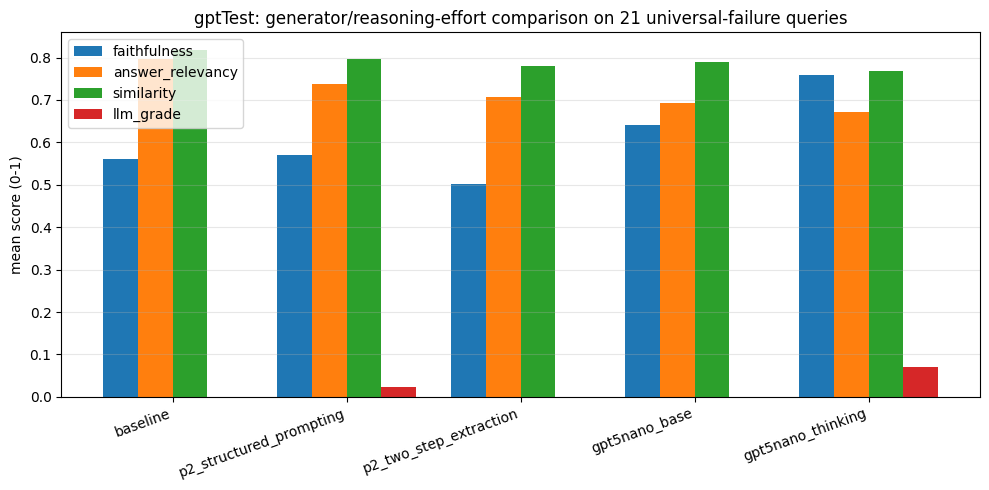

Saved to figures\comparison.png


In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(VARIANT_ORDER))
width = 0.2
for i, metric in enumerate(METRICS):
    offsets = [xi + (i - 1.5) * width for xi in x]
    ax.bar(offsets, summary_by_variant[metric], width=width, label=metric)
ax.set_xticks(list(x))
ax.set_xticklabels(VARIANT_ORDER, rotation=20, ha="right")
ax.set_ylabel("mean score (0-1)")
ax.set_title("gptTest: generator/reasoning-effort comparison on 21 universal-failure queries")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison.png", dpi=150)
plt.show()
print(f"Saved to {FIG_DIR / 'comparison.png'}")


### Findings (21 universal-failure queries, `hybrid` config, means pooled over both reference models unless noted)

| Variant | Faithfulness | Answer relevancy | Similarity | `llm_grade` (of 42) |
|---|---|---|---|---|
| baseline (Llama-3.1-8B) | 0.561 | 0.798 | 0.819 | 0/42 |
| P2v1 structured prompting | 0.570 | 0.738 | 0.796 | 1/42 |
| P2v2 two-step extraction | 0.502 | 0.707 | 0.780 | 0/42 |
| **gpt5nano_base** (minimal effort) | 0.641 | 0.694 | 0.791 | 0/42 |
| **gpt5nano_thinking** (medium effort) | **0.758** | 0.673 | 0.768 | **3/42** |

**Swapping the generator alone (Llama-3.1-8B → gpt-5-nano, no reasoning) improves
faithfulness (0.561→0.641) but does not move correctness at all** (`llm_grade` stays at
the 0/42 floor these 21 queries were selected for) — a different provider/architecture
at a comparably modest capability tier isn't sufficient by itself.

**Adding reasoning (medium effort) is the first thing in this whole P1/P2/gptTest
lineage to move `llm_grade` off the floor**: 3/42 pass, all of them `exact_anchor`
queries (`0.188` mean vs `0.0` for every other variant on `exact_anchor`) — genuinely
none of the gain comes from `cross_reference` queries (still `0.0` there for every
variant, gptTest included). This is a real, useful negative-within-positive finding: the
original motivation for testing thinking was the cross-reference synthesis bottleneck
identified in P1, but the actual gain shows up on `exact_anchor` queries instead — the
queries that don't require synthesizing across multiple clauses at all. Worth
investigating further (read the 3 newly-passing rows directly) before concluding thinking
helps synthesis; on this evidence it looks more like thinking helps precision/completeness
on single-clause questions, not multi-clause synthesis.

**Faithfulness rises monotonically with reasoning effort** (0.561 baseline → 0.641
minimal → 0.758 medium) **while answer_relevancy and similarity both decline slightly**
in the same order. Plausible read: more reasoning makes the model stick closer to what
the retrieved clauses actually say (helping faithfulness) but also makes answers more
literal/clause-bound and less naturally phrased relative to the reference (hurting
relevancy/similarity) — consistent with the earlier finding that `answer_relevancy` was
also lower for the 70B generator vs 8B (bigger/more-capable models being less "on-topic"
by this particular metric, not more).

**`reasoning_effort="high"` is unusable for `gpt-5-nano` on this task** (see `plan.md`
Change log) — a standalone methodological finding independent of the thinking-vs-not
comparison above.

### Caveats
- Single run per condition, not repeated — OpenAI reasoning models aren't guaranteed
  deterministic even at a fixed effort level, unlike the local Llama runs.
- n=21 (42/84 scored rows) is a deliberately small gate, matching `dynamic_rrf`'s and
  `query_type_retrieval`'s scale — not a basis for scaling to the full 200-row set without
  first reading the 3 newly-passing rows and confirming the exact_anchor-specific gain is
  real and not noise.
- `answer_relevancy`/`similarity` softening with more reasoning is a small effect (≤0.03)
  on a 21-query sample — worth confirming at larger n before treating as a stable
  trade-off.

In [21]:
passing = comparison_df[(comparison_df["variant"] == "gpt5nano_thinking") & (comparison_df["llm_grade"] == 1.0)]
print(passing[["query", "reference_model", "faithfulness", "answer_relevancy", "similarity"]].to_string())
print("\n--- Full answers for these queries (thinking condition) ---\n")
for q in passing["query"].unique():
    row = next(r for r in thinking_answers if r["query"] == q)
    print(f"Q: {q}\n")
    print(f"A: {row['answer']}\n")
    print("=" * 100)


                                                                                                                                               query reference_model  faithfulness  answer_relevancy  similarity
167               What three conditions must all be satisfied for a person to commit the failure-to-disclose offence under section 330 of POCA 2002?             14b           1.0          0.698633    0.797848
202  Under MLR 2017 regulation 29, when must a credit institution or financial institution identify the beneficiary of a long-term insurance policy?             72b           1.0          0.616555    0.765451
209               What three conditions must all be satisfied for a person to commit the failure-to-disclose offence under section 330 of POCA 2002?             72b           1.0          0.698633    0.784614

--- Full answers for these queries (thinking condition) ---

Q: What three conditions must all be satisfied for a person to commit the failure-to-disclose offence 

In [22]:
baseline_answers_full = load_jsonl(MAIN_RESULTS_DIR / "answers_recovered.jsonl")
for q in passing["query"].unique():
    base_row = next(r for r in baseline_answers_full if r["query"] == q and r["config"] == "hybrid")
    nano_row = next(r for r in nonthinking_answers if r["query"] == q)
    print(f"Q: {q}\n")
    print(f"[baseline Llama-3.1-8B]: {base_row['answer']}\n")
    print(f"[gpt5nano_base]: {nano_row['answer']}\n")
    print("=" * 100)


Q: What three conditions must all be satisfied for a person to commit the failure-to-disclose offence under section 330 of POCA 2002?

[baseline Llama-3.1-8B]: A person commits an offence under section 330 of POCA 2002 if the conditions in subsections (2) to (4) are satisfied. The first condition is that he— a knows or suspects, or b has reasonable grounds for knowing or suspecting, that another person is engaged in money laundering [poca_2002_s330(2)]. The second condition is that the information or other matter— a on which his knowledge or suspicion is based, or b which gives reasonable grounds for such knowledge or suspicion, came to him in the course of a business in the regulated sector [poca_2002_s330(3)]. The third condition is— a that he can identify the other person mentioned in subsection (2) or the whereabouts of any of the laundered property, or b that he believes, or it is reasonable to expect him to believe, that the information or other matter mentioned in subsection (3)

## Cell group 8: extend to all four retrieval configs (sparse_only, dense_only, dense_sparse)

`hybrid` was tested first (matching the P1/P2 precedent). Extending to the other three
configs, reusing each config's already-recorded `retrieved` clause IDs from
`p1_universal_failures.jsonl` (`answers_8b.{config}.retrieved`) — no new retrieval needed.
Same two conditions (`minimal`/non-thinking, `medium`/thinking), same 21 queries.

In [ ]:
REMAINING_CONFIGS = ["dense_only", "sparse_only", "dense_sparse"]

# sanity: confirm every failure row has retrieved context recorded for all 3 configs
missing = [row["query"] for row in failures if not all(c in row["answers_8b"] for c in REMAINING_CONFIGS)]
print(f"Rows missing one of {REMAINING_CONFIGS}: {len(missing)}")
assert not missing


def generate_condition_for_config(reasoning_effort: str, variant: str, config: str, out_path: Path) -> None:
    n_errors = 0
    with out_path.open("w", encoding="utf-8") as f:
        for i, row in enumerate(failures, start=1):
            query = row["query"]
            retrieved_ids = row["answers_8b"][config]["retrieved"]
            context = format_context(retrieved_ids, clause_lookup)
            t0 = time.time()
            answer, citations, error = "", [], None
            try:
                resp = client.chat.completions.create(
                    model=GEN_MODEL,
                    messages=[
                        {"role": "system", "content": SYSTEM_PROMPT.format(context=context)},
                        {"role": "user", "content": query},
                    ],
                    response_format={"type": "json_object"},
                    max_completion_tokens=MAX_COMPLETION_TOKENS,
                    reasoning_effort=reasoning_effort,
                )
                content = resp.choices[0].message.content
                if not content:
                    error = f"empty content, finish_reason={resp.choices[0].finish_reason!r}"
                else:
                    parsed = json.loads(content)
                    answer = parsed.get("answer", "")
                    citations = parsed.get("citations", [])
            except Exception as exc:
                error = f"{type(exc).__name__}: {exc}"
                n_errors += 1

            out = {
                "query": query, "query_type": row["query_type"], "gold_ids": row["gold_ids"],
                "config": config, "variant": variant, "reasoning_effort": reasoning_effort,
                "retrieved": retrieved_ids, "answer": answer, "citations": citations,
                "error": error,
            }
            f.write(json.dumps(out, ensure_ascii=False) + "\n")
            f.flush()

    print(f"[{config}/{variant}] Done: {len(failures)} rows -> {out_path} ({n_errors} errors)")


print("Generating non-thinking (minimal) for remaining configs...")
for cfg in REMAINING_CONFIGS:
    generate_condition_for_config("minimal", "gpt5nano_base", cfg, OUT_DIR / f"answers_nonthinking_{cfg}.jsonl")


Rows missing one of ['dense_only', 'sparse_only', 'dense_sparse']: 0
Generating non-thinking (minimal) for remaining configs...


In [ ]:
print("Generating thinking (medium) for remaining configs...")
for cfg in REMAINING_CONFIGS:
    generate_condition_for_config("medium", "gpt5nano_thinking", cfg, OUT_DIR / f"answers_thinking_{cfg}.jsonl")


Generating thinking (medium) for remaining configs...


## Cell group 9: score the remaining 3 configs

Same methodology as cell group 5 (faithfulness/answer_relevancy via RAGAS + `gpt-5.5`,
similarity + `llm_grade` vs both reference models). Scores the 126 new rows (3 configs x
2 conditions x 21 queries), then combines with the existing `hybrid` scores into one
full `scores_all.jsonl`.

In [ ]:
extra_answers = []
for cfg in REMAINING_CONFIGS:
    extra_answers += load_jsonl(OUT_DIR / f"answers_nonthinking_{cfg}.jsonl")
    extra_answers += load_jsonl(OUT_DIR / f"answers_thinking_{cfg}.jsonl")

n_errors_extra = sum(1 for r in extra_answers if r.get("error"))
print(f"Loaded {len(extra_answers)} new rows across {REMAINING_CONFIGS} (expect {21*2*3}=126), {n_errors_extra} errors")

extra_faith_inputs = [
    dict(user_input=r["query"], response=r["answer"],
         retrieved_contexts=[clause_lookup[cid]["text"] for cid in r["retrieved"] if cid in clause_lookup])
    for r in extra_answers
]
extra_rel_inputs = [dict(user_input=r["query"], response=r["answer"]) for r in extra_answers]

print("Scoring faithfulness + answer_relevancy for the 126 new rows...")
extra_faith_results = await metric_faithfulness.abatch_score(extra_faith_inputs)
extra_rel_results = await metric_answer_relevancy.abatch_score(extra_rel_inputs)
print("Done.")


Loaded 126 new rows across ['dense_only', 'sparse_only', 'dense_sparse'] (expect 126=126), 0 errors
Scoring faithfulness + answer_relevancy for the 126 new rows...


In [29]:
EXTRA_SCORES_PATH = OUT_DIR / "scores_extra_configs.jsonl"

with EXTRA_SCORES_PATH.open("w", encoding="utf-8") as f:
    for ref_name in ["reference_14b", "reference_72b"]:
        ref_short = ref_name.removeprefix("reference_")
        answer_texts = [r["answer"] for r in extra_answers]
        reference_texts = [ts_lookup[r["query"]][ref_name] for r in extra_answers]
        print(f"Scoring correctness against {ref_short}...")
        sims = await cosine_similarities_batch(answer_texts, reference_texts)
        grades = await asyncio.gather(*[
            llm_correctness_grade(r["query"], ref, r["answer"])
            for r, ref in zip(extra_answers, reference_texts)
        ])
        for row, f_res, r_res, sim, grade in zip(extra_answers, extra_faith_results, extra_rel_results, sims, grades):
            out = {
                "query": row["query"], "query_type": row["query_type"], "config": row["config"],
                "variant": row["variant"], "reasoning_effort": row["reasoning_effort"],
                "reference_model": ref_short,
                "faithfulness": f_res.value, "answer_relevancy": r_res.value,
                "similarity": sim, "llm_grade": grade,
            }
            f.write(json.dumps(out, ensure_ascii=False) + "\n")

print(f"Done: scores written to {EXTRA_SCORES_PATH}")


Scoring correctness against 14b...


Scoring correctness against 72b...


Done: scores written to results\scores_extra_configs.jsonl


## Cell group 10: full comparison across all four configs

Rebuilds the baseline join (cell group 6 only used `hybrid`) across all four configs,
combines with all `gptTest` scores (`hybrid` from `scores.jsonl` + the 3 new configs from
`scores_extra_configs.jsonl`), and plots GPT generation metrics faceted by
`dense_only`/`sparse_only`/`dense_sparse`/`hybrid`.

In [30]:
ALL_CONFIGS = ["dense_only", "sparse_only", "dense_sparse", "hybrid"]

baseline_rows_all = []
for row in correctness_baseline:
    if row["config"] not in ALL_CONFIGS or row["query"] not in failure_queries:
        continue
    ragas_row = next(
        (r for r in ragas_answer_baseline if r["config"] == row["config"] and r["query"] == row["query"]), {}
    )
    baseline_rows_all.append({
        "query": row["query"], "query_type": row["query_type"], "config": row["config"],
        "variant": "baseline", "reference_model": row["ref_model"],
        "faithfulness": ragas_row.get("faithfulness"), "answer_relevancy": ragas_row.get("answer_relevancy"),
        "similarity": row["cosine_sim"], "llm_grade": row["llm_grade"],
    })

extra_scores = load_jsonl(EXTRA_SCORES_PATH)
gpt_scores_all_configs = scores + extra_scores  # scores = hybrid (from cell group 5), extra = the other 3

print(f"baseline_rows_all: {len(baseline_rows_all)} (expect {21*4*2}=168)")
print(f"gpt_scores_all_configs: {len(gpt_scores_all_configs)} (expect {21*4*2*2}=336: 4 configs x 2 conditions x 21 queries x 2 ref models)")

full_comparison_df = pd.DataFrame(baseline_rows_all + gpt_scores_all_configs)
full_comparison_df.to_csv(OUT_DIR / "comparison_all_configs.csv", index=False)
print(f"\nWrote {len(full_comparison_df)} rows to {OUT_DIR / 'comparison_all_configs.csv'}")

pivot = full_comparison_df.groupby(["config", "variant"])[METRICS].mean().reindex(
    ALL_CONFIGS, level=0
).reindex(["baseline", "gpt5nano_base", "gpt5nano_thinking"], level=1)
print(pivot.round(3))


baseline_rows_all: 168 (expect 168=168)
gpt_scores_all_configs: 336 (expect 336=336: 4 configs x 2 conditions x 21 queries x 2 ref models)

Wrote 504 rows to results\comparison_all_configs.csv
                                faithfulness  answer_relevancy  similarity  \
config       variant                                                         
dense_only   baseline                  0.440             0.740       0.799   
             gpt5nano_base             0.577             0.800       0.802   
             gpt5nano_thinking         0.739             0.682       0.744   
sparse_only  baseline                  0.601             0.792       0.811   
             gpt5nano_base             0.616             0.672       0.807   
             gpt5nano_thinking         0.717             0.567       0.715   
dense_sparse baseline                  0.527             0.785       0.825   
             gpt5nano_base             0.557             0.747       0.802   
             gpt5nano_think

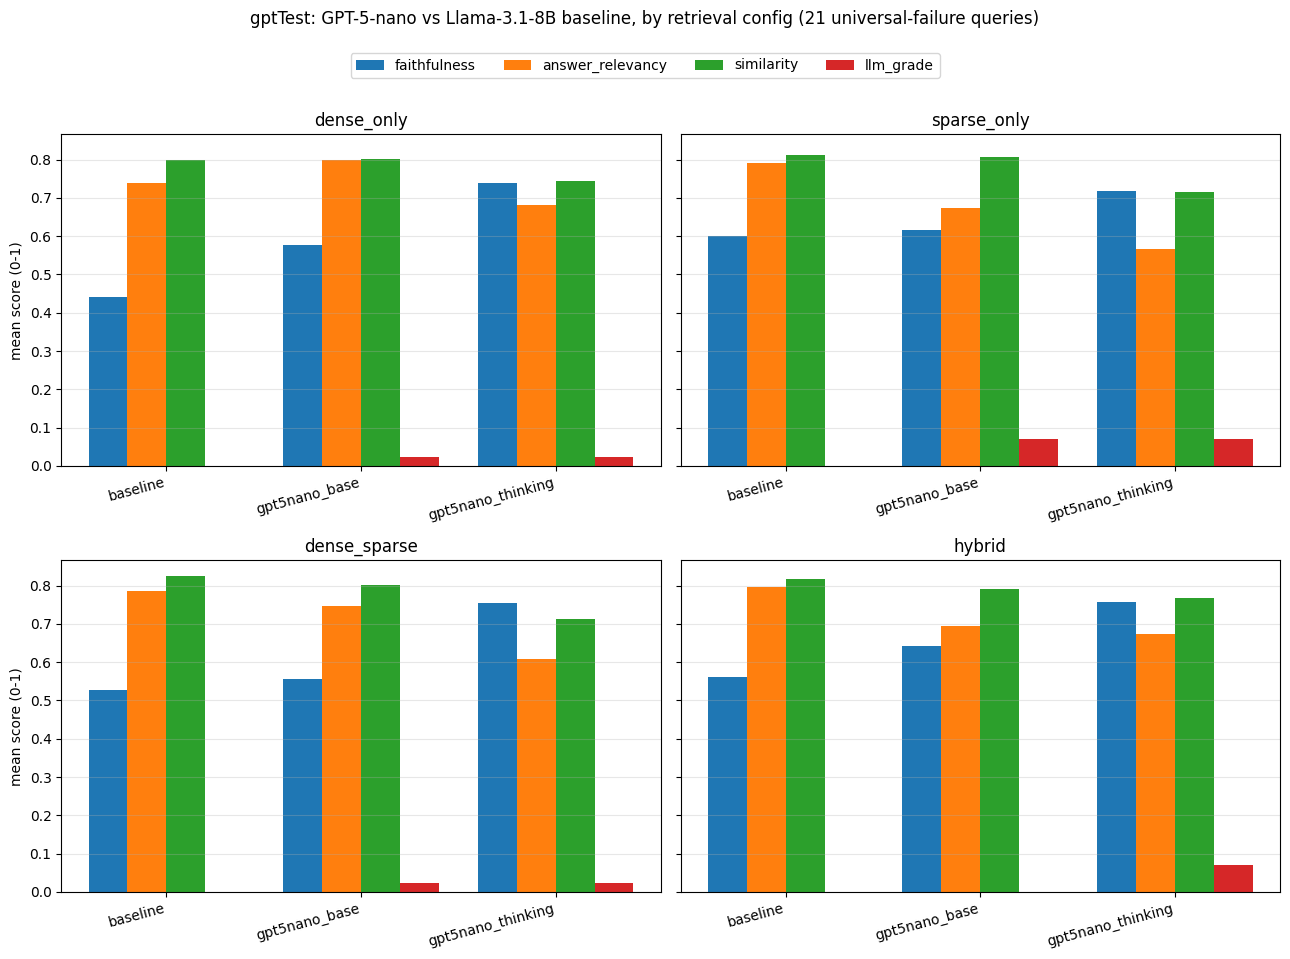

Saved to figures\comparison_all_configs.png


In [31]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharey=True)
variant_order2 = ["baseline", "gpt5nano_base", "gpt5nano_thinking"]

for ax, cfg in zip(axes.flat, ALL_CONFIGS):
    sub = pivot.loc[cfg].reindex(variant_order2)
    x = range(len(variant_order2))
    width = 0.2
    for i, metric in enumerate(METRICS):
        offsets = [xi + (i - 1.5) * width for xi in x]
        ax.bar(offsets, sub[metric], width=width, label=metric if cfg == "hybrid" else None)
    ax.set_xticks(list(x))
    ax.set_xticklabels(variant_order2, rotation=15, ha="right")
    ax.set_title(cfg)
    ax.grid(axis="y", alpha=0.3)

axes[0, 0].set_ylabel("mean score (0-1)")
axes[1, 0].set_ylabel("mean score (0-1)")
fig.legend(*axes[0, 1].get_legend_handles_labels() if axes[0,1].get_legend_handles_labels()[0] else axes.flat[-1].get_legend_handles_labels(),
           loc="upper center", ncol=4, bbox_to_anchor=(0.5, 1.02))
fig.suptitle("gptTest: GPT-5-nano vs Llama-3.1-8B baseline, by retrieval config (21 universal-failure queries)", y=1.06)
fig.tight_layout()
fig.savefig(FIG_DIR / "comparison_all_configs.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved to {FIG_DIR / 'comparison_all_configs.png'}")


### Findings, extended to all four retrieval configs

| Config | Variant | Faithfulness | Answer relevancy | Similarity | `llm_grade` |
|---|---|---|---|---|---|
| dense_only | baseline | 0.440 | 0.740 | 0.799 | 0.000 |
| dense_only | gpt5nano_base | 0.577 | 0.800 | 0.802 | 0.024 |
| dense_only | gpt5nano_thinking | 0.739 | 0.682 | 0.744 | 0.024 |
| sparse_only | baseline | 0.601 | 0.792 | 0.811 | 0.000 |
| sparse_only | gpt5nano_base | 0.616 | 0.672 | 0.807 | **0.071** |
| sparse_only | gpt5nano_thinking | 0.717 | 0.567 | 0.715 | **0.071** |
| dense_sparse | baseline | 0.527 | 0.785 | 0.825 | 0.000 |
| dense_sparse | gpt5nano_base | 0.557 | 0.747 | 0.802 | 0.024 |
| dense_sparse | gpt5nano_thinking | 0.755 | 0.608 | 0.713 | 0.024 |
| hybrid | baseline | 0.561 | 0.798 | 0.819 | 0.000 |
| hybrid | gpt5nano_base | 0.641 | 0.694 | 0.791 | 0.000 |
| hybrid | gpt5nano_thinking | 0.758 | 0.673 | 0.768 | **0.071** |

**The faithfulness gain from swapping to GPT-5-nano holds across every config, not just
hybrid** — baseline faithfulness ranges 0.440-0.601 across configs; both GPT conditions
beat baseline in every single config, and `gpt5nano_thinking` beats baseline by the
largest margin in every config (+0.14 to +0.30).

**Answer_relevancy/similarity decline with reasoning effort in every config** — the
pattern noted for `hybrid` alone (relevancy/similarity trade off against faithfulness as
reasoning effort increases) generalizes across all four configs, not a hybrid-specific
artifact.

**`llm_grade` correctness gains are not hybrid-specific either — `sparse_only` shows the
same-sized gain as `hybrid`, and it appears already at the non-thinking (`gpt5nano_base`)
condition**, unlike `hybrid` where the gain only appears with thinking. This weakens the
"thinking is what unlocks correctness" reading from the hybrid-only result: for
`sparse_only`, just switching the generator (no added reasoning) already produces the
same 3-row gain that `hybrid` needed thinking to reach. `dense_only`/`dense_sparse` show
a smaller, config-plateaued gain (1 row passing, same at both reasoning levels) that
doesn't grow with reasoning effort at all.

**Revised read**: the correctness gain from GPT-5-nano is real but small and doesn't
cleanly track reasoning effort the way `hybrid` alone suggested — different configs hit
their (still small) ceiling via different mechanisms. This is a more honest picture than
the hybrid-only result on its own implied, and argues against reading too much into the
"thinking helps" story from a single config.